In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/attc-dataset/TestV2 - testV2.csv
/kaggle/input/attc-dataset/trainV2.csv


# **Installing necessary libraries**

In [2]:
# %%
!pip install -q transformers datasets accelerate scikit-learn matplotlib seaborn

# **Importing necessary libraries**

In [3]:
# %%
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

2026-03-04 13:44:02.092967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772631842.285533      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772631842.344669      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772631842.793031      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772631842.793070      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772631842.793072      55 computation_placer.cc:177] computation placer alr

# **Load Dataset**

In [4]:
# %%
train_df = pd.read_csv("/kaggle/input/attc-dataset/trainV2.csv")
test_df  = pd.read_csv("/kaggle/input/attc-dataset/TestV2 - testV2.csv")

train_df = train_df.dropna().reset_index(drop=True)
test_df  = test_df.dropna().reset_index(drop=True)

label2id = {"Non-Abusive":0, "Abusive":1, "abusive":1}
id2label = {0:"Non-Abusive", 1:"Abusive"}

train_df["label"] = train_df["Class"].map(label2id)

train_df.head()

,Text,Class,label
0,நான் கூட உன்னை வெகுளியான பொண்ணு&#39;னு நெனச்சி...,Non-Abusive,0
1,உன் போட்டோவை டாய்லெட்டுக்கு மாற்றினார்கள் அசிங...,Abusive,1
2,கண்டா வரச்சொல்லுங்க கார்த்திய திவ்யாவோட சேர்த்...,Non-Abusive,0
3,ஒன்னோட சைசுக்கு நீயே ஒரு நாளக்கி 5கிலோ ஆய் போவ...,Abusive,1
4,ரெண்டும் மிக பெரிய வெடிகுண்டு இவங்கள எதுக்கு ஷ...,Non-Abusive,0


# **Dataset Overview**

In [5]:
# %%
print("Train size:", len(train_df))
print("Test size:", len(test_df))

train_df["Class"].value_counts()

Train size: 3652
Test size: 913


Class
Non-Abusive    1883
Abusive        1768
abusive           1
Name: count, dtype: int64

# **Class Distribution**

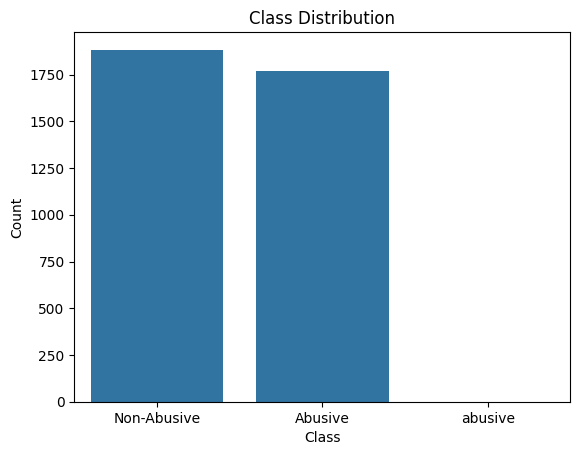

In [6]:
# %%
plt.figure()

sns.countplot(x=train_df["Class"])

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

# **Text Length Distribution**

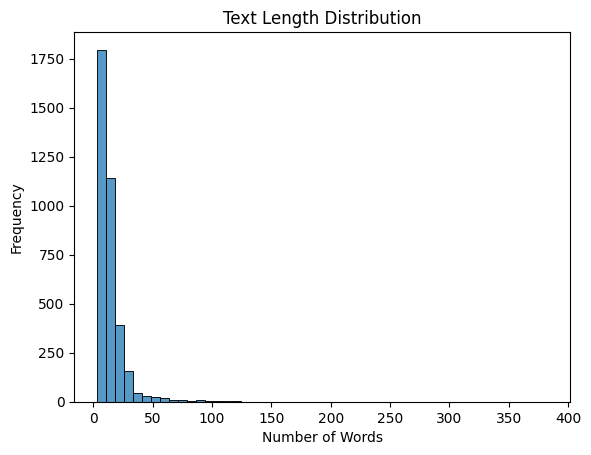

In [7]:
# %%
train_df["text_length"] = train_df["Text"].apply(lambda x: len(x.split()))

plt.figure()

sns.histplot(train_df["text_length"], bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# **Train Validation Split**

In [8]:
# %%
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["Text"].tolist(),
    train_df["label"].tolist(),
    test_size=0.15,
    stratify=train_df["label"],
    random_state=SEED
)

# **Dataset Class**

In [9]:
# %%
class AbuseDataset(torch.utils.data.Dataset):

    def __init__(self, texts, tokenizer, labels=None):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=128
        )

        if self.labels is not None:
            enc["labels"] = self.labels[idx]

        return enc

# **Class Weights**

In [10]:
# %%
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

# **Custom Trainer**

In [11]:
# %%
class WeightedTrainer(Trainer):

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.model.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels = inputs["labels"]

        outputs = model(**inputs)

        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)

        loss = loss_fct(logits.view(-1,2), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# **Evaluation Metrics**

In [12]:
# %%
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    macro_f1 = f1_score(labels, preds, average="macro")

    return {"macro_f1": macro_f1}

# **Tokenizer & Dataset**

In [13]:
# %%
MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = AbuseDataset(train_texts, tokenizer, train_labels)
val_dataset   = AbuseDataset(val_texts, tokenizer, val_labels)
test_dataset  = AbuseDataset(test_df["Text"].tolist(), tokenizer)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

# **Load Model**

In [14]:
# %%
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
).cuda()

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# **Training Arguments**

In [15]:
# %%
training_args = TrainingArguments(

    output_dir="./xlm_roberta",

    eval_strategy="epoch",

    save_strategy="no",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    fp16=True,

    logging_steps=100,

    report_to="none",

    seed=SEED
)

# **Trainer**

In [16]:
# %%
trainer = WeightedTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    tokenizer=tokenizer,

    data_collator=DataCollatorWithPadding(tokenizer),

    compute_metrics=compute_metrics,

    class_weights=class_weights
)

/tmp/ipykernel_55/4250625395.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


# **Train Model**

In [17]:
# %%
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.610027,0.643978
2,0.662200,0.564803,0.748855
3,0.551500,0.504810,0.767907


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=291, training_loss=0.5682026446889766, metrics={'train_runtime': 177.1226, 'train_samples_per_second': 52.574, 'train_steps_per_second': 1.643, 'total_flos': 497921227827840.0, 'train_loss': 0.5682026446889766, 'epoch': 3.0})

# **Extract Loss Values**

In [18]:
# %%
logs = trainer.state.log_history

train_loss = []
val_loss = []

for log in logs:

    if "loss" in log:
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        val_loss.append(log["eval_loss"])

# **Training Loss Plot**

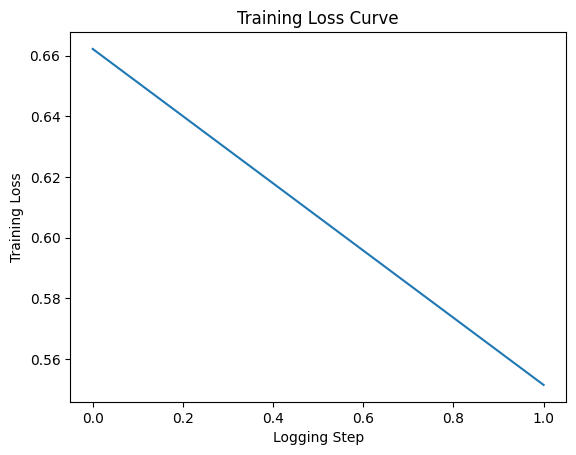

In [19]:
# %%
plt.figure()

plt.plot(train_loss)

plt.xlabel("Logging Step")
plt.ylabel("Training Loss")

plt.title("Training Loss Curve")

plt.show()

# **Validation Loss Plot**

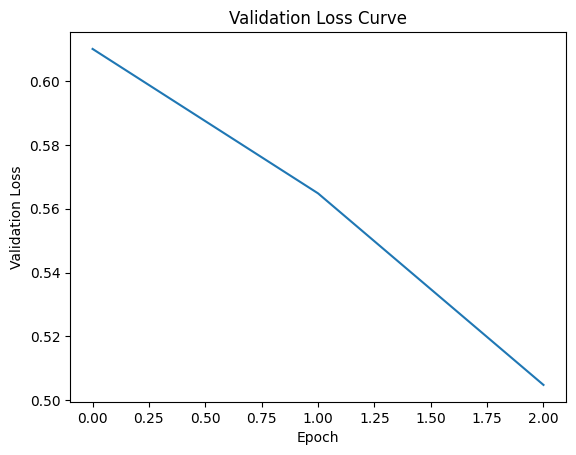

In [20]:
# %%
plt.figure()

plt.plot(val_loss)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title("Validation Loss Curve")

plt.show()

# **Combined Loss Plot**

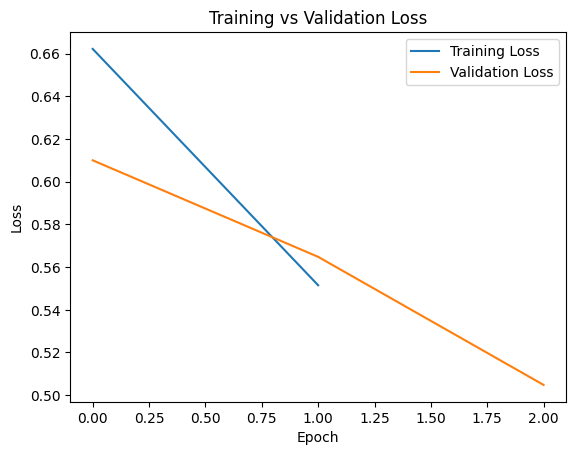

In [21]:
# %%
plt.figure()

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

# **Validation Prediction**

In [22]:
# %%
val_output = trainer.predict(val_dataset)

val_logits = val_output.predictions

val_probs = torch.softmax(torch.tensor(val_logits), dim=1).numpy()[:,1]

val_preds = np.argmax(val_logits, axis=1)

print(classification_report(val_labels, val_preds))

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.82      0.71      0.76       283
           1       0.73      0.83      0.78       265

    accuracy                           0.77       548
   macro avg       0.77      0.77      0.77       548
weighted avg       0.77      0.77      0.77       548



# **Confusion Matrix**

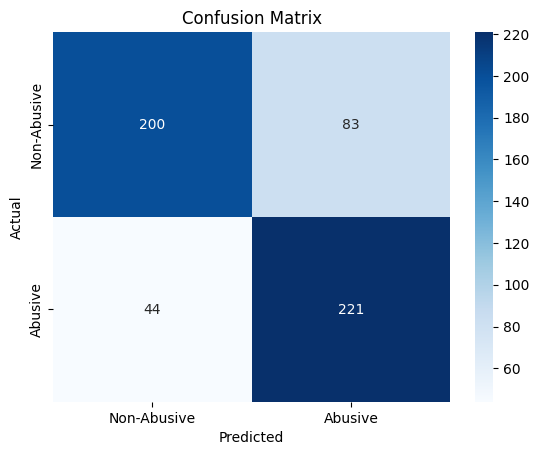

In [23]:
# %%
cm = confusion_matrix(val_labels, val_preds)

path = "confusion_matrix.png"

plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Abusive","Abusive"],
    yticklabels=["Non-Abusive","Abusive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig(path)

plt.show()

# **ROC Curve**

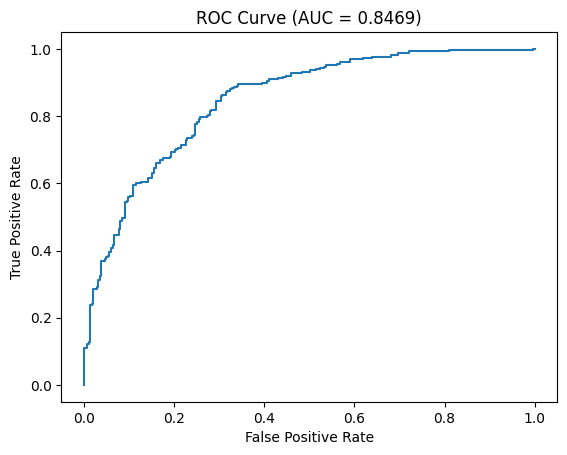

In [24]:
# %%
fpr, tpr, _ = roc_curve(val_labels, val_probs)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")

plt.show()

# **Test Prediction**

In [25]:
# %%
test_output = trainer.predict(test_dataset)

test_preds = np.argmax(test_output.predictions, axis=1)

# **Create Submission**

In [26]:
# %%
submission = pd.DataFrame({

    "Text": test_df["Text"],

    "Standard": [id2label[x] for x in test_preds]

})

submission.to_csv("submission.csv", index=False)

submission.head()

,Text,Standard
0,லக்ஷ்மி அம்மா நீங்க புலம்புங்க அவளுக அவளுகபாட்...,Non-Abusive
1,"இன்னும் கைது பண்ணல... அனைத்து பெற்றோர்களும், க...",Non-Abusive
2,"அப்பா,அம்மா, அந்த இன்டர்வியூ பண்ற வக்கிரம்புடி...",Abusive
3,Suganthi உனக்கு வீட்ல குழந்தையை வச்சிருக்க கார...,Non-Abusive
4,எல்லாமே script thaan. ஷகீலா உங்க scriptum அரும...,Non-Abusive
